# Student's t Distribution

The **t distribution** arises when estimating the mean of a normally distributed population from a small sample when the population variance is unknown. It has heavier tails than the Normal — the uncertainty about σ adds extra variability — but converges to N(0,1) as degrees of freedom increase.

| Property | Value |
|---|---|
| **Parameter** | $\nu$ (degrees of freedom, $\nu > 0$) |
| **Support** | $(-\infty, +\infty)$ |
| **PDF** | $\displaystyle f(x) = \frac{\Gamma\!\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\,\Gamma\!\left(\frac{\nu}{2}\right)} \left(1 + \frac{x^2}{\nu}\right)^{-(\nu+1)/2}$ |
| **Mean** | $0$ (undefined for $\nu=1$) |
| **Variance** | $\nu/(\nu-2)$ for $\nu > 2$; undefined for $\nu \leq 2$ |
| **Skewness** | $0$ (symmetric) |
| **Kurtosis** | $6/(\nu-4) + 3$ for $\nu > 4$ (heavy tails) |
| **Special cases** | $\nu=1 \to$ Cauchy; $\nu \to \infty \to N(0,1)$ |
| **Primary use** | t-tests, confidence intervals when $\sigma$ is unknown |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the t Distribution

### Panel 1 — PDF: Tail Thickness by Degrees of Freedom
Each curve shows the **PDF** of $t(\nu)$ for increasing degrees of freedom. At $\nu=1$ (Cauchy), the tails are extremely heavy. As $\nu$ grows, the PDF converges to the standard Normal $N(0,1)$ (dashed grey line).

### Panel 2 — Critical Value $t_{0.975}$ vs $\nu$
The **two-tailed critical value** at $\alpha=0.05$ falls steeply for small $\nu$ and converges to $z_{0.975}=1.96$ (red dashed line). This is why small-sample inference requires wider confidence intervals than the z-based approach.

### Panel 3 — One-Sample t-Test Demonstration
The $t(n-1)$ distribution is the null distribution of the test statistic $T = (\bar{x}-\mu_0)/(s/\sqrt{n})$ under $H_0$. The red shaded regions mark the rejection zone ($\alpha=0.05$); the orange vertical line shows the observed test statistic and its two-tailed p-value.


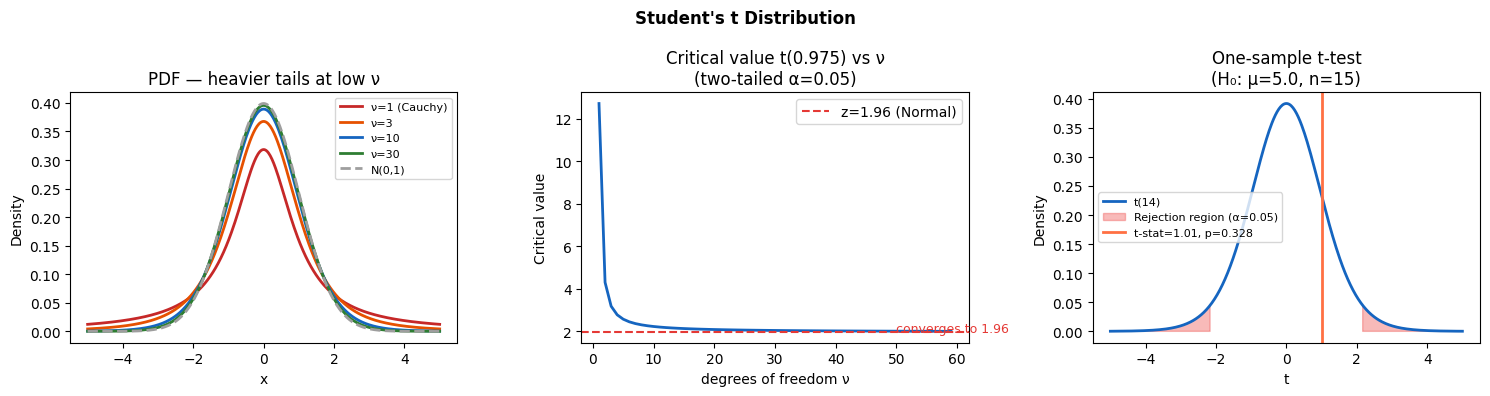

Sample: n=15, x̄=5.52, s=1.99
t-statistic=1.014, df=14, p-value=0.3277
Critical value t(0.975, df=14) = 2.145


In [2]:
x = np.linspace(-5, 5, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Student's t Distribution", fontsize=12, fontweight='bold')

# PDF — varying df
for df, color, label in [(1,  '#C62828', 'ν=1 (Cauchy)'),
                          (3,  '#E65100', 'ν=3'),
                          (10, '#1565C0', 'ν=10'),
                          (30, '#2E7D32', 'ν=30')]:
    axes[0].plot(x, stats.t(df).pdf(x), color=color, linewidth=2, label=label)
axes[0].plot(x, stats.norm(0,1).pdf(x), color='#9E9E9E', linewidth=2,
             linestyle='--', label='N(0,1)')
axes[0].set_title('PDF — heavier tails at low ν')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Critical values vs df (two-tailed α=0.05)
dfs = np.arange(1, 60)
t_crit = [stats.t(df).ppf(0.975) for df in dfs]
axes[1].plot(dfs, t_crit, color='#1565C0', linewidth=2)
axes[1].axhline(stats.norm.ppf(0.975), color='#E53935', linewidth=1.5,
                linestyle='--', label=f'z=1.96 (Normal)')
axes[1].set_title('Critical value t(0.975) vs ν\n(two-tailed α=0.05)')
axes[1].set_xlabel('degrees of freedom ν')
axes[1].set_ylabel('Critical value')
axes[1].legend()
axes[1].annotate('converges to 1.96', xy=(50, 1.97), fontsize=9, color='#E53935')

# t-test demonstration
np.random.seed(42)
n = 15
sample = np.random.normal(loc=5.5, scale=2, size=n)  # true mean = 5.5
null_mu = 5.0
t_stat, p_val = stats.ttest_1samp(sample, null_mu)
df_t = n - 1
t_range = np.linspace(-5, 5, 400)
axes[2].plot(t_range, stats.t(df_t).pdf(t_range), color='#1565C0', linewidth=2,
             label=f't({df_t})')
t_crit_val = stats.t(df_t).ppf(0.975)
axes[2].fill_between(t_range, stats.t(df_t).pdf(t_range),
                     where=(np.abs(t_range) >= t_crit_val),
                     color='#EF5350', alpha=0.4, label=f'Rejection region (α=0.05)')
axes[2].axvline(t_stat, color='#FF7043', linewidth=2,
                label=f't-stat={t_stat:.2f}, p={p_val:.3f}')
axes[2].set_title(f'One-sample t-test\n(H₀: μ={null_mu}, n={n})')
axes[2].set_xlabel('t'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Sample: n={n}, x̄={sample.mean():.2f}, s={sample.std(ddof=1):.2f}")
print(f"t-statistic={t_stat:.3f}, df={df_t}, p-value={p_val:.4f}")
print(f"Critical value t(0.975, df={df_t}) = {t_crit_val:.3f}")

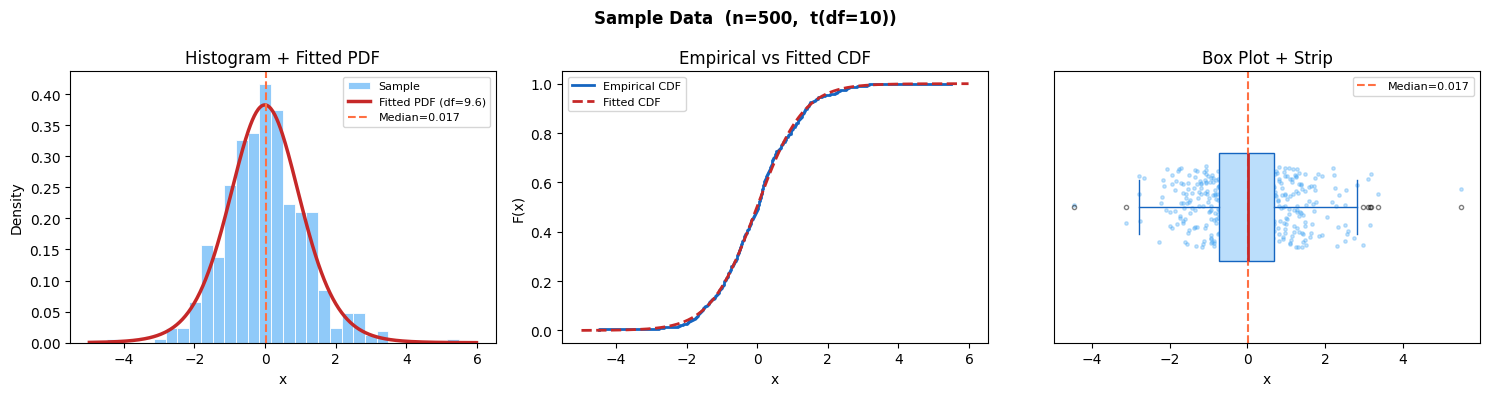

n=500  mean=0.0115  median=0.0172  std=1.1447  skew=0.2795  kurtosis=1.2130


In [3]:
# Sample data plots — t(df=10)
np.random.seed(42)
sample_d = stats.t.rvs(df=10, size=500)
df_hat, loc_hat, scale_hat = stats.t.fit(sample_d)
x_fit = np.linspace(sample_d.min() - 0.5, sample_d.max() + 0.5, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  t(df=10))', fontsize=12, fontweight='bold')

# Histogram + fitted PDF
axes[0].hist(sample_d, bins=30, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.6, label='Sample')
axes[0].plot(x_fit, stats.t(df_hat, loc_hat, scale_hat).pdf(x_fit),
             color='#C62828', linewidth=2.5, label=f'Fitted PDF (df={df_hat:.1f})')
axes[0].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Empirical vs fitted CDF
sorted_s = np.sort(sample_d)
ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, stats.t(df_hat, loc_hat, scale_hat).cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# Box plot + strip
axes[2].boxplot(sample_d, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=3, alpha=0.5))
axes[2].scatter(sample_d, np.random.uniform(0.85, 1.15, len(sample_d)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[2].set_title('Box Plot + Strip')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"n={len(sample_d)}  mean={sample_d.mean():.4f}  median={np.median(sample_d):.4f}  std={sample_d.std(ddof=1):.4f}  skew={stats.skew(sample_d):.4f}  kurtosis={stats.kurtosis(sample_d):.4f}")


## Key Takeaways

| | |
|---|---|
| **ν=1** | Reduces to Cauchy — no mean, very heavy tails |
| **ν→∞** | Converges to N(0,1) — practically Normal at ν≥30 |
| **Heavier tails** | Wider confidence intervals than z-based — accounts for unknown $\sigma$ |
| **t-test** | $T = (\bar{x} - \mu_0)/(s/\sqrt{n}) \sim t(n-1)$ under $H_0$ |
| **Two-sample t-test** | Compares means of two groups; df from Welch's formula if variances differ |
| **Practical rule** | Use t (not z) whenever $\sigma$ is unknown, regardless of sample size |
| **Critical values** | $t_{0.975}(10)=2.23$;  $t_{0.975}(30)=2.04$;  $t_{0.975}(\infty)=1.96$ |
